In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth' , None)
pd.set_option('display.max_columns' , None)
pd.set_option('display.max_rows' , None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,not available,27.0,North,1 to 5 Year Old,"['IFFCO Chowk Metro Station', 'The Esplanade Mall', 'Dhanwapur Road', 'Dwarka Expressway', 'Govt. PG College', 'Delhi Public School', 'The NorthCap University', 'Shree Krishna Hospital', 'Indira Gandhi International Airport', 'Basai Dhankot', 'The Executive Centre', 'Park Inn', ""Oyster's Water Park"", 'DLF Golf and Country Club']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 sq.yards (209.03 sq.m.)Carpet area: 200 sq.yards (167.23 sq.m.),4,4,3,"servant room,study room,pooja room,store room",2.0,North,1 to 5 Year Old,"['Sector 55-56 Metro Station', 'Airia Mall', 'Sohna Road', 'Faridabad Gurgaon Road', 'St Xavier High School', 'Gurugram University', 'Park Hospital', 'IGI Airport', 'M3M IFC', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '12 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,"others,servant room",5.0,West,5 to 10 Year Old,"['City Square', 'Vatika Town Square', 'Bharat Ram Global School', 'Shishu Kalyan School', 'DSD College', 'Amity University', 'ICFAI University', 'Canara Bank ATM', 'Axis Bank ATM', 'Arc Hospital', 'Rathore IMT Hospital', 'Indira Gandhi Airport', 'Yes Bank', 'Canara Bank', 'Patil Station']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,not available,8.0,NaN,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Esic Hospital Gurugram', 'Shri Multispeciality Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Ashok Jain', 'Taneja Hospital', 'Pearl Dental Clinic', 'Kr Dental Hub', 'Ankur Clinic and Maternity Home', 'Dr. Madan Clinic', 'Navjeevan Hospital and Maternity Centre', 'Shiv Mahima Patient Care Bureau', 'Prateek Nursing Home And Polyclinic', 'Dev Man Kathuria Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Shri Gobind Hospital', 'Lal Superspeciality Hospital', 'Satyam Hospital Gurgaon', 'Chiranjiv Hospital', 'Kamla Hospital Gurgaon', 'Geeta Nursing Home Gurgaon', 'Swastik Maternity and Medical Centre', 'Aryan Hospital', 'Bhanu Dental Care', 'Tirath Ram Hospitals Pvt Ltd', 'Gurga

In [5]:
df.duplicated().sum()

122

In [6]:
df.sample(5)[['price' , 'area' , 'areaWithType']]

,price,area,areaWithType
2096,6.46,3420.0,Plot area 380(317.73 sq.m.)Built Up area: 380 sq.yards (317.73 sq.m.)Carpet area: 300 sq.yards (250.84 sq.m.)
3707,1.10,1150.0,Super Built up area 1640(152.36 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1150 sq.ft. (106.84 sq.m.)
2800,1.23,1350.0,Super Built up area 1350(125.42 sq.m.)
3044,0.75,1300.0,Carpet area: 1300 (120.77 sq.m.)
3199,1.30,2860.0,Super Built up area 2860(265.7 sq.m.)


In [7]:
df['areaWithType'].value_counts()

areaWithType
Plot area 360(301.01 sq.m.)                                                                                                     37
Plot area 300(250.84 sq.m.)                                                                                                     26
Plot area 200(167.23 sq.m.)                                                                                                     19
Plot area 502(419.74 sq.m.)                                                                                                     19
Plot area 270(225.75 sq.m.)                                                                                                     17
Super Built up area 1578(146.6 sq.m.)                                                                                           17
Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.)                                                   17
Super Built up area 1350(125.42 sq.m.)                                

In [8]:
#The function that extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None


In [9]:
#The function that extracts the Built Up area or Carpet area
def get_area(text , area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [10]:
#this function checks if the area is in sq.m. and converts to sqft if needed
def convert_to_sqft(text , area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639
    return area_value

In [11]:
#Extract super built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'] , x['super_built_up_area']) , axis = 1)

#extract build up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x , 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [12]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
430,1.50,flat,1750.0,Super Built up area 1750(162.58 sq.m.)Built Up area: 1466 sq.ft. (136.2 sq.m.),1750.0,1466.0,NaN
3518,0.46,flat,900.0,Carpet area: 900 (83.61 sq.m.),NaN,NaN,900.0
1275,3.00,house,2700.0,Carpet area: 2700 (250.84 sq.m.),NaN,NaN,2700.0
2184,1.30,flat,2040.0,Built Up area: 2040 (189.52 sq.m.),NaN,2040.0,NaN
835,1.25,flat,1960.0,Super Built up area 1960(182.09 sq.m.),1960.0,NaN,NaN


In [13]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [14]:
df.shape

(3802, 20)

In [15]:
df[df['areaWithType'].str.contains('Plot')][['price' , 'property_type' , 'area' , 'areaWithType' , 'super_built_up_area' , 'built_up_area' , 'carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.8,house,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 sq.yards (209.03 sq.m.)Carpet area: 200 sq.yards (167.23 sq.m.),NaN,250.0,200.0
11,1.2,house,846.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq.ft. (78.6 sq.m.),NaN,846.0,NaN
18,12.0,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
23,5.0,house,2250.0,Plot area 250(209.03 sq.m.),NaN,NaN,NaN
29,13.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [16]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          980
features                635
super_built_up_area    1887
built_up_area          2615
carpet_area            1859
dtype: int64

In [17]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [18]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
18,12.0,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
23,5.0,house,2250.0,Plot area 250(209.03 sq.m.),NaN,NaN,NaN
29,13.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
34,6.8,house,2160.0,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
43,8.5,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [19]:
all_nan_df.shape

(546, 7)

In [20]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [21]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [22]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [23]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2732,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.0,NaN
3183,9.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN
1215,0.75,house,713.0,Plot area 713(66.24 sq.m.),NaN,713.0,NaN
900,5.75,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.0,NaN
1057,11.95,house,2745.0,Plot area 305(255.02 sq.m.),NaN,305.0,NaN


In [24]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0: #1 Square Yard = 9 Square Feet
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0: # for vigha / gaj
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [25]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [26]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
18,12.0,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN
23,5.0,house,2250.0,Plot area 250(209.03 sq.m.),NaN,2250.0,NaN
29,13.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
34,6.8,house,2160.0,Plot area 240(200.67 sq.m.),NaN,2160.0,NaN
43,8.5,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN


In [27]:
df.update(all_nan_df)

In [28]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          980
features                635
super_built_up_area    1887
built_up_area          2069
carpet_area            1859
dtype: int64

In [29]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1586
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [30]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']


In [31]:
#populate the new columns based on the additionalRoom column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [32]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
703,pooja room,0,0,0,1,0
430,not available,0,0,0,0,0
2868,servant room,0,1,0,0,0
162,servant room,0,1,0,0,0
125,others,0,0,0,0,1


In [33]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,not available,27.0,North,1 to 5 Year Old,"['IFFCO Chowk Metro Station', 'The Esplanade Mall', 'Dhanwapur Road', 'Dwarka Expressway', 'Govt. PG College', 'Delhi Public School', 'The NorthCap University', 'Shree Krishna Hospital', 'Indira Gandhi International Airport', 'Basai Dhankot', 'The Executive Centre', 'Park Inn', ""Oyster's Water Park"", 'DLF Golf and Country Club']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",NaN,NaN,6500.0,0,0,0,0,0
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 sq.yards (209.03 sq.m.)Carpet area: 200 sq.yards (167.23 sq.m.),4,4,3,"servant room,study room,pooja room,store room",2.0,North,1 to 5 Year Old,"['Sector 55-56 Metro Station', 'Airia Mall', 'Sohna Road', 'Faridabad Gurgaon Road', 'St Xavier High School', 'Gurugram University', 'Park Hospital', 'IGI Airport', 'M3M IFC', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '12 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,250.0,200.0,1,1,1,1,0
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,"others,servant room",5.0,West,5 to 10 Year Old,"['City Square', 'Vatika Town Square', 'Bharat Ram Global School', 'Shishu Kalyan School', 'DSD College', 'Amity University', 'ICFAI University', 'Canara Bank ATM', 'Axis Bank ATM', 'Arc Hospital', 'Rathore IMT Hospital', 'Indira Gandhi Airport', 'Yes Bank', 'Canara Bank', 'Patil Station']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']",1930.0,NaN,NaN,0,1,0,0,1
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,not available,8.0,NaN,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Esic Hospital Gurugram', 'Shri Multispeciality Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Ashok Jain', 'Taneja Hospital', 'Pearl Dental Clinic', 'Kr Dental Hub', 'Ankur Clinic and Maternity Home', 'Dr. Madan Clinic', 'Navjeevan Hospital and Maternity Centre', 'Shiv Mahima Patient Care Bureau', 'Prateek Nursing Home And Polyclinic', 'Dev Man Kathuria Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Shri Gobind Hospital', 'Lal Superspeciality Hospital', 'Satyam Hospital Gurgaon', 'Chiranjiv Hospital'

In [34]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      89
Within 6 months         70
Within 3 months         26
Dec-23                  22
By 2023                 19
By 2024                 17
Dec-24                  16
Mar-24                  14
Jan-24                   8
Oct-24                   8
Dec-25                   7
Aug-23                   7
Jun-24                   7
Nov-23                   5
Aug-24                   4
By 2025                  4
Oct-23                   4
Jul-24                   4
Sep-23                   4
Jan-25                   3
May-24                   3
Nov-24                   3
Feb-24                   3
By 2027                  2
Jun-27                   2
Jul-25                   2
Sep-25                   2
Jan-26                   2
Oct-25                   2
Aug-25                   2
Dec-26                   2
Jul-27        

In [35]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [36]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [37]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              484
Old Property           310
Under Construction     131
Name: count, dtype: int64

In [38]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2205,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
135,[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
1080,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
2432,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Visitor Parking', 'Fitness Centre / GYM', 'Club house / Community Center']"
2814,NaN,"['High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"


In [39]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [43]:
furnishings_df.head()

,Sofa,Bed,Stove,Dining Table,Chimney,Light,Fridge,Geyser,TV,Curtains,Washing Machine,Modular Kitchen,Wardrobe,Fan,Exhaust Fan,Microwave,Water Purifier,AC
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,12,0,4,0,0,0,1,5,6,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,12,0,3,0,0,0,0,4,6,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [41]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\virat\AppData\Local\Temp\ipykernel_21128\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [48]:
wcss_reduced = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i , init = 'k-means++' , random_state = 42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

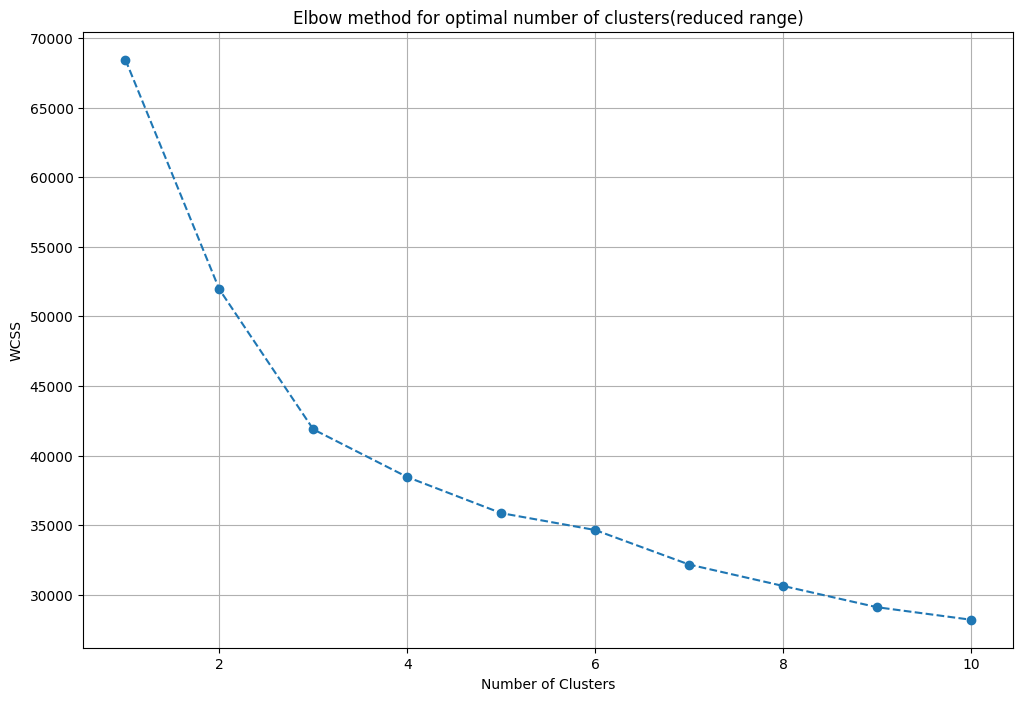

In [49]:
plt.figure(figsize = (12 , 8))
plt.plot(range(1,11) , wcss_reduced , marker = 'o' , linestyle = '--')
plt.title('Elbow method for optimal number of clusters(reduced range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [50]:
n_clusters = 3

kmeans = KMeans(n_clusters = n_clusters , random_state = 42)
kmeans.fit(scaled_data)

cluster_assignments = kmeans.predict(scaled_data)

In [52]:
df.shape

(3802, 43)

In [53]:
df = df.iloc[:,:-18]

In [54]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,not available,27.0,North,Relatively New,"['IFFCO Chowk Metro Station', 'The Esplanade Mall', 'Dhanwapur Road', 'Dwarka Expressway', 'Govt. PG College', 'Delhi Public School', 'The NorthCap University', 'Shree Krishna Hospital', 'Indira Gandhi International Airport', 'Basai Dhankot', 'The Executive Centre', 'Park Inn', ""Oyster's Water Park"", 'DLF Golf and Country Club']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",NaN,NaN,6500.0,0,0,0,0,0
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 sq.yards (209.03 sq.m.)Carpet area: 200 sq.yards (167.23 sq.m.),4,4,3,"servant room,study room,pooja room,store room",2.0,North,Relatively New,"['Sector 55-56 Metro Station', 'Airia Mall', 'Sohna Road', 'Faridabad Gurgaon Road', 'St Xavier High School', 'Gurugram University', 'Park Hospital', 'IGI Airport', 'M3M IFC', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '12 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,250.0,200.0,1,1,1,1,0
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,"others,servant room",5.0,West,Moderately Old,"['City Square', 'Vatika Town Square', 'Bharat Ram Global School', 'Shishu Kalyan School', 'DSD College', 'Amity University', 'ICFAI University', 'Canara Bank ATM', 'Axis Bank ATM', 'Arc Hospital', 'Rathore IMT Hospital', 'Indira Gandhi Airport', 'Yes Bank', 'Canara Bank', 'Patil Station']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']",1930.0,NaN,NaN,0,1,0,0,1
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,not available,8.0,NaN,Relatively New,"['Chintapurni Mandir', 'State bank ATM', 'Esic Hospital Gurugram', 'Shri Multispeciality Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Ashok Jain', 'Taneja Hospital', 'Pearl Dental Clinic', 'Kr Dental Hub', 'Ankur Clinic and Maternity Home', 'Dr. Madan Clinic', 'Navjeevan Hospital and Maternity Centre', 'Shiv Mahima Patient Care Bureau', 'Prateek Nursing Home And Polyclinic', 'Dev Man Kathuria Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Shri Gobind Hospital', 'Lal Superspeciality Hospital', 'Satyam Hospital Gurgaon', 'Chiranjiv Hospital', 'Ka

In [55]:
df['furnishing_type'] = cluster_assignments

In [57]:
df['furnishing_type']

0       1
1       0
2       1
3       0
4       1
5       2
6       1
7       1
8       0
9       1
10      2
11      0
12      1
13      1
14      0
15      0
16      1
17      1
18      0
19      0
20      1
21      0
22      0
23      1
24      1
25      1
26      1
27      1
28      1
29      0
30      0
31      1
32      0
33      0
34      1
35      1
36      1
37      1
38      0
39      0
40      1
41      1
42      1
43      1
44      1
45      1
46      1
47      0
48      1
49      2
50      1
51      1
52      1
53      1
54      1
55      1
56      0
57      1
58      0
59      0
60      1
61      1
62      0
63      1
64      0
65      0
66      0
67      1
68      2
69      0
70      1
71      1
72      0
73      1
74      1
75      0
76      1
77      0
78      1
79      0
80      1
81      0
82      0
83      1
84      1
85      0
86      1
87      0
88      1
89      1
90      1
91      0
92      1
93      0
94      0
95      1
96      1
97      0
98      0
99      1


In [59]:
df.sample(5)[['furnishDetails' , 'furnishing_type']]
#0 unfurnished
#1 semifurnished
#2 furnished

,furnishDetails,furnishing_type
1450,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
3416,"['4 Fan', '8 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
2181,"['1 Wardrobe', '1 Fan', '1 Light', '1 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
773,"['1 Water Purifier', '1 Exhaust Fan', '6 Geyser', '1 Stove', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine']",0
2393,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Geyser', '12 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0


In [60]:
df[['society' , 'features']].sample(5)

,society,features
3659,supertech basera,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Piped-gas', 'Security Personnel', 'Internet/wi-fi connectivity', 'Club house / Community Center', 'Rain Water Harvesting', 'Water softening plant']"
3274,dlf the primus,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1876,m3m woodshire,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2799,m3m merlin,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
856,Uppal Southend4.0 ★,"['Feng Shui / Vaastu Compliant', 'Maintenance Staff', 'Park', 'Rain Water Harvesting']"


In [61]:
df['features'].isnull().sum()

635

In [62]:
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [63]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [64]:
temp_df = df[df['features'].isnull()]

In [66]:
temp_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
4,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,not available,19.0,NaN,Moderately Old,"['MDS Public School', 'St Pauls School', 'Suncity School', 'Hanuman & Shani Mandir', 'IndusInd Bank ATM', 'SGT UHTC Basai', 'K.D. Hospital', 'CANARA BANK', 'State Bank of India', 'Basai Enclave Park', 'Ramprastha Police Post', 'Taxila cricket ground', 'Bharat Singh fuel company', 'Edge towers tennis court', 'KFG Sports Club']",NaN,NaN,NaN,1410.0,NaN,0,0,0,0,0,1
6,flat,hcbs sports ville,sohna road,0.30,4011.0,748.0,Built Up area: 743 (69.03 sq.m.)Carpet area: 621 sq.ft. (57.69 sq.m.),2,2,2,not available,3.0,NaN,Undefined,"['The roadside cafe', 'GD Goenka Mess', 'ROyal Kitchen', 'Mithaas Wala', 'Momomia Gurgoan']",NaN,NaN,NaN,743.0,621.0,0,0,0,0,0,1
17,flat,trisara our homes 3,sohna road,0.38,6312.0,602.0,Built Up area: 602 (55.93 sq.m.),2,2,2,not available,1.0,NaN,Undefined,"['Metro Station', 'Gyanchand Market', 'Rajiv Chowk', 'KMP Expressway', 'Govt.Sr.Sec School(boys)', 'Jindal College', 'Kidzee', 'Vishvakarma Mandir', 'Mamta Hospital', 'Fortis', 'IGI T3', 'Oriental Bank of Commerce', 'Rajiv Gandhi Park']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,602.0,NaN,0,0,0,0,0,1
19,flat,nul,gwal pahari,0.56,6054.0,925.0,Carpet area: 925 (85.94 sq.m.),2,2,1,not available,11.0,NaN,Old Property,"['HANUMAN MANDIR', 'SHIV MANDIR BALIYAWAS', 'Indusind bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Parivar Clinic', 'Janki Max Hospital', 'Arunodaya Deseret Eye Hospital', 'Apollo Pharmacy', 'Intellion Park', 'International Tech Park', 'Hdfc bank', 'Icici bank', 'CHINESE CORNER', 'Naivedyam Restaurant', 'GOVERNMENT SCHOOL', 'Regional Skill Development Centre', 'Suncity School', 'Ansal Institute of Technology', 'Sushant College of Arts & Architecture']","['4 Fan', '1 Exhaust Fan', '18 Light', '2 AC', '4 Wardrobe', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,NaN,925.0,0,0,0,0,0,0
24,flat,chanderlok society,sector 28,0.90,7234.0,1244.0,Carpet area: 1244 (115.57 sq.m.),4,2,3+,not available,1.0,NaN,Old Property,"['Iffco chowk metro station', 'Mg road metro station', 'Standard chartered ATM', 'Kotak mahindra bank ATM', 'Icici bank ATM', 'Punjab national bank ATM', 'Axis bank ATM', 'Rbs ATM', 'Sidhesh Hospital Gurgaon', 'Sitaram Bhartia', 'Umkal Hospital', 'Lord Krishna Hospital', 'Privat Hospital', 'Max Hospital', 'Uma Sanjeevani Health Centre And Hospital', 'Religare Wellness', '98.4', 'Guardian', 'Chikitsa', 'Axis bank', 'Indusind bank', 'Abn amro bank', 'Lord krishna bank', 'Hdfc bank', 'Kotak mahindra bank', 'Hsbc bank', 'DT Cinemas', 'PVR Metropolitan', 'PVR Cinames', 'PVR Cinames', 'DT Cinemas', 'Barbecue Grill', 'Dighent cafe', 'Belgian Waffle', 'Drunken Monkey', 'CCD', 'Fat', 'Nowhere Brewpub and cafe', 'Blue Tokai Coffee Roasters', 'Starbucks', 'Pizza Hut', 'Naveidyam', 'NutrioBox Gurugram', 'Pan Bangkok', 'The Chicken Boat', 'Roots', 'Bahrisons library', 'Ncr library']",NaN,NaN,NaN,NaN,1244.0,0,0,0,0,0,1


In [67]:
x = temp_df.merge(app_df , left_on = 'society' , right_on = 'PropertyName' , how = 'left')['TopFacilities']

In [68]:
df.loc[temp_df.index , 'features'] = x.values

In [69]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [70]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [71]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2706,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
353,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
807,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
578,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2304,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [72]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

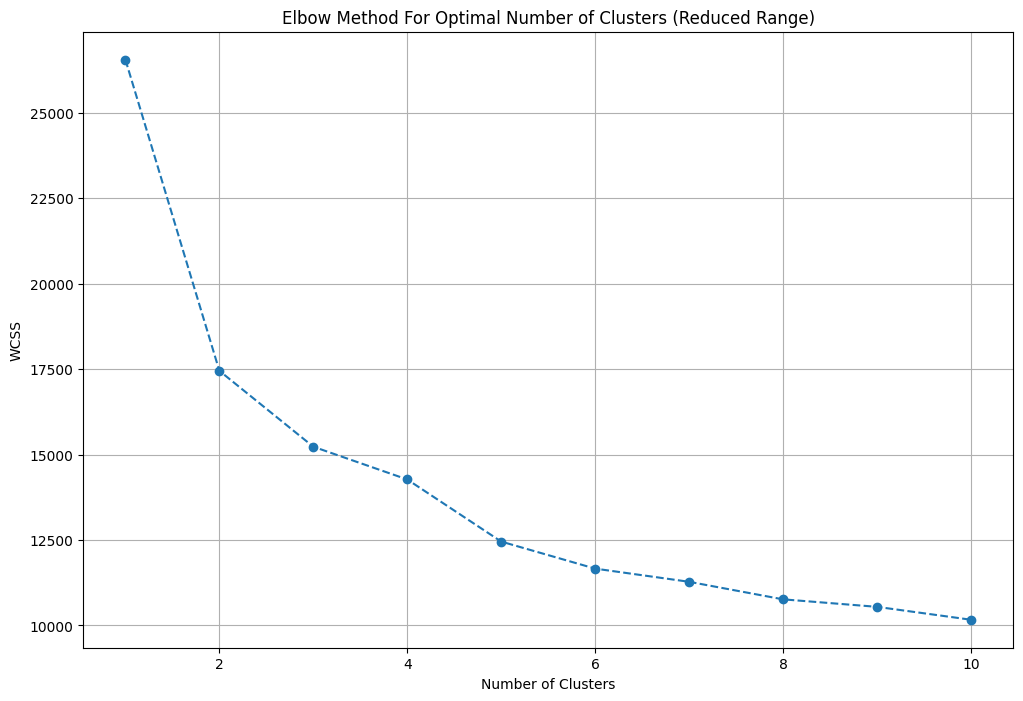

In [73]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [75]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}

In [76]:
# 1. Find the common features between your weights and the actual columns
common_features = [feature for feature in weights.keys() if feature in features_binary_df.columns]

# 2. Extract only those common weights
filtered_weights = {feature: weights[feature] for feature in common_features}

# 3. Calculate the luxury score using only the features that exist
luxury_score = features_binary_df[common_features].multiply(list(filtered_weights.values())).sum(axis=1)

# 4. Add it to our main dataframe
df['luxury_score'] = luxury_score

In [77]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,not available,27.0,North,Relatively New,"['IFFCO Chowk Metro Station', 'The Esplanade Mall', 'Dhanwapur Road', 'Dwarka Expressway', 'Govt. PG College', 'Delhi Public School', 'The NorthCap University', 'Shree Krishna Hospital', 'Indira Gandhi International Airport', 'Basai Dhankot', 'The Executive Centre', 'Park Inn', ""Oyster's Water Park"", 'DLF Golf and Country Club']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",NaN,NaN,6500.0,0,0,0,0,0,1,"[Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Visitor Parking, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Fitness Centre / GYM, Rain Water Harvesting, Club house / Community Center, Water softening plant]",110
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 sq.yards (209.03 sq.m.)Carpet area: 200 sq.yards (167.23 sq.m.),4,4,3,"servant room,study room,pooja room,store room",2.0,North,Relatively New,"['Sector 55-56 Metro Station', 'Airia Mall', 'Sohna Road', 'Faridabad Gurgaon Road', 'St Xavier High School', 'Gurugram University', 'Park Hospital', 'IGI Airport', 'M3M IFC', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '12 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,250.0,200.0,1,1,1,1,0,0,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, Piped-gas, Visitor Parking, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center]",103
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,"others,servant room",5.0,West,Moderately Old,"['City Square', 'Vatika Town Square', 'Bharat Ram Global School', 'Shishu Kalyan School', 'DSD College', 'Amity University', 'ICFAI University', 'Canara Bank ATM', 'Axis Bank ATM', 'Arc Hospital', 'Rathore IMT Hospital', 'Indira Gandhi Airport', 'Yes Bank', 'Canara Bank', 'Patil Station']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/w

In [78]:
df['luxury_score'].value_counts()

luxury_score
0      501
49     352
174    196
44      62
38      58
72      56
165     55
60      50
37      49
42      46
45      44
7       43
15      43
65      38
31      38
67      38
21      35
158     34
79      33
95      31
8       30
24      30
35      29
26      29
61      29
160     28
110     27
66      27
96      26
22      26
88      26
101     25
28      25
23      25
16      24
103     24
108     23
53      23
43      23
56      23
120     23
86      23
159     23
58      22
74      22
156     22
117     22
157     22
52      21
167     21
51      20
111     20
80      20
81      20
149     20
119     19
152     19
153     19
150     18
27      18
36      18
151     18
20      18
105     17
94      17
125     17
126     17
29      17
102     17
100     17
76      16
40      16
57      16
77      16
54      16
30      15
68      15
55      15
113     15
59      15
128     15
90      15
99      15
75      15
109     15
71      15
104     15
46      14
142     14
135     

In [79]:
df.drop(columns = ['nearbyLocations' , 'furnishDetails' , 'features' , 'features_list' , 'additionalRoom'] , inplace = True)

In [80]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
526,flat,eldeco accolade,sector 33,1.20,8043.0,1492.0,Built Up area: 1492 (138.61 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,2,0.0,NaN,Undefined,NaN,1492.0,849.0,0,0,0,0,0,1,56
3793,flat,ireo the corridors,sector 67a,2.00,11580.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet area: 1017 sq.ft. (94.48 sq.m.),3,3,2,6.0,NaN,Under Construction,1727.0,NaN,1017.0,0,0,0,0,1,1,15
2792,flat,m3m heights,sector 65,2.01,13500.0,1489.0,Super Built up area 1516(140.84 sq.m.)Carpet area: 1433 sq.ft. (133.13 sq.m.),2,2,3,8.0,North-East,New Property,1516.0,NaN,1433.0,1,0,0,0,0,1,44
1127,flat,ild greens,sector 37c,0.90,5614.0,1603.0,Super Built up area 1603(148.92 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.),3,3,3,0.0,North-East,Under Construction,1603.0,1500.0,NaN,0,0,0,0,0,1,66
102,flat,chd avenue,sector 71,1.20,7407.0,1620.0,Super Built up area 1620(150.5 sq.m.),3,3,3,4.0,North,Relatively New,1620.0,NaN,NaN,0,0,0,0,1,0,49


In [81]:
df.shape

(3802, 23)

In [82]:
df.to_csv('gurgaon_properties_cleaned_v2.csv' , index = False)